In [ ]:
# create and save PSTH
from nwb_utils import NWBUtils
from behavior_utils import extract_fitted_data, find_trials,get_fitted_model_names,generate_behavior_summary
from create_psth import extract_neuron_psth_to_zarr

session_name='764787_2024-12-11_15-01-15_sorted_2025-02-21_17-11-57'
#session_name='764790_2024-12-19_16-11-34'
print(get_fitted_model_names(session_name=session_name))

nwb_data,tag=NWBUtils.combine_nwb(session_name=session_name)

psth_da = extract_neuron_psth_to_zarr(
    nwb_data       = nwb_data,
    align_to_event = ["go_cue","reward_go_cue_start"],
    time_window    = (-6, 6),
    bin_size       = 0.1,
    save_folder    = "/root/capsule/results",
    save_name      = "psth_mouse123",
)

In [ ]:
from nwb_utils import NWBUtils
from behavior_utils import extract_fitted_data, find_trials,get_fitted_model_names,generate_behavior_summary
from create_psth import extract_neuron_psth_to_zarr
session_name='764787_2024-12-11_15-01-15_sorted_2025-02-21_17-11-57'
#session_name='764790_2024-12-19_16-11-34'
print(get_fitted_model_names(session_name=session_name))

nwb_data,tag=NWBUtils.combine_nwb(session_name=session_name)

In [ ]:
from create_psth import  load_psth_raster_from_zarr, mean_firing_rate_matrix,load_zarr
from behavior_utils import find_trials

# 0.  Load the pre‑computed PSTH cube
#psth_da = load_psth_raster_from_zarr("/root/capsule/results/psth_mouse123.zarr",align_to_event='go_cue',load_type='both')
psth_full = load_zarr("/root/capsule/results/psth_mouse123.zarr")

In [ ]:
psth_full

In [ ]:
from create_psth import load_psth_raster_subset
psth,raster=load_psth_raster_subset(psth_full,align_to_event='go_cue')

In [ ]:
# ---------------------------------------------------------------------
# EXAMPLE ── integrate with your existing code
# ---------------------------------------------------------------------
import numpy as np
from create_psth import load_psth_raster_from_zarr, load_psth_raster_from_zarr, mean_firing_rate_matrix, plot_psth_raster_for_units,load_zarr
from behavior_utils import find_trials

# 0.  Load the pre‑computed PSTH cube
psth_da = load_zarr("/root/capsule/results/psth_mouse123.zarr")

# 1.  Pick trials of interest
# 2) convert → numpy array  (enables vectorised −1)
switch_trials_reward=np.asarray(find_trials(nwb_data,'switch_trial_reward'))
switch_trials_noreward=np.asarray(find_trials(nwb_data,'switch_trial_noreward'))
#switch_trials = np.asarray(switch_trials, dtype=int)

# 3) one trial earlier
#previous_trial_ids = switch_trials

#valid_prev_trial_ids  = previous_trial_ids[previous_trial_ids >= 0]  # safety

# 2.  Plot PSTH for three units over those trials
fig = plot_psth_raster_for_units(
    source=psth_da, 
    align_to_event='go_cue',         
    trial_ids=[[switch_trials_reward+1],[switch_trials_noreward+1]],
    time_window=(-3, 6),
    save_path="/root/capsule/results/",
    plot_type='mean'
)

In [11]:
psth_da

<xarray.Dataset> Size: 4GB
Dimensions:                          (unit: 530, trial_go_cue: 513, time: 120,
                                      trial_reward_go_cue_start: 204,
                                      spike: 2754)
Coordinates:
  * spike                            (spike) int64 22kB 0 1 2 ... 2751 2752 2753
  * time                             (time) float64 960B -5.95 -5.85 ... 5.95
    trial_index_go_cue               (trial_go_cue) int64 4kB 0 1 2 ... 511 512
    trial_index_reward_go_cue_start  (trial_reward_go_cue_start) int64 2kB ...
    unit_index                       (unit) int64 4kB 11 13 17 ... 1422 1423
Dimensions without coordinates: unit, trial_go_cue, trial_reward_go_cue_start
Data variables:
    psth_go_cue                      (unit, trial_go_cue, time) float32 131MB ...
    psth_reward_go_cue_start         (unit, trial_reward_go_cue_start, time) float32 52MB ...
    raster_go_cue                    (unit, trial_go_cue, spike) float32 3GB ...
    raster_reward_go_cue_start       (unit, trial_reward_go_cue_start, spike) float32 1GB ...
Attributes:
    align_to_events:     ['go_cue', 'reward_go_cue_start']
    bin_size:            0.1
    created_with:        extract_neuron_psth_to_zarr
    n_trials_per_event:  {'go_cue': 513, 'reward_go_cue_start': 204}
    n_units:             530
    session_id:          behavior_764787_2024-12-11_15-01-15.json

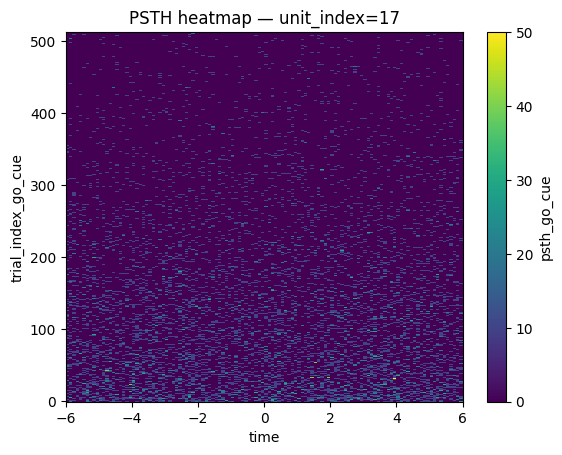

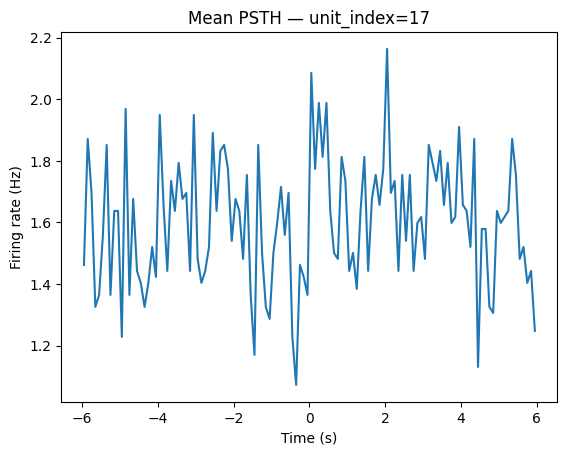

In [23]:
import matplotlib.pyplot as plt

# 1) Use the coordinate values as the dimension labels
psth_labeled = psth_da.swap_dims({
    "unit": "unit_index",
    "trial_go_cue": "trial_index_go_cue"
})["psth_go_cue"]   # dims: (unit_index, trial_index_go_cue, time)

# 2) Select by labels
unit_id = 17
psth_single = psth_labeled.sel(unit_index=unit_id)                # (trial_index_go_cue, time)

# 3) Heatmap across trials
psth_single.plot()
plt.title(f"PSTH heatmap — unit_index={unit_id}")
plt.show()

# 4) Trial-averaged PSTH
psth_mean = psth_single.mean(dim="trial_index_go_cue")
psth_mean.plot(x="time")
plt.title(f"Mean PSTH — unit_index={unit_id}")
plt.xlabel("Time (s)")
plt.ylabel("Firing rate (Hz)")
plt.show()


<xarray.DataArray 'psth_go_cue' (time: 120)> Size: 480B
[120 values with dtype=float32]
Coordinates:
  * time                (time) float64 960B -5.95 -5.85 -5.75 ... 5.75 5.85 5.95
    trial_index_go_cue  int64 8B 9
    unit_index          int64 8B 13
Attributes:
    align_to_event:  go_cue
    bin_size:        0.1
    time_window:     [-6, 6]
    trial_type:      all


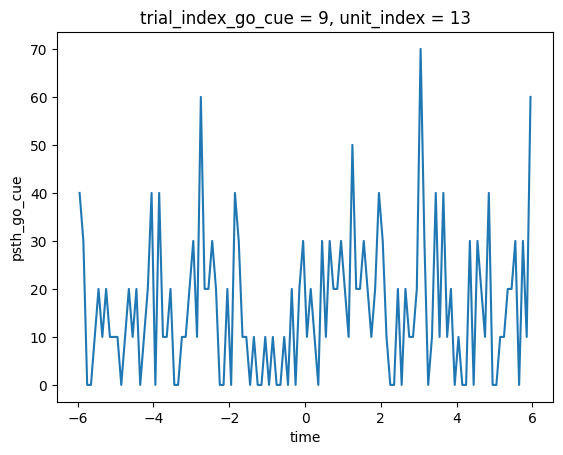

In [18]:
# Select by integer index
psth_single = psth_da['psth_go_cue'].isel(unit=1, trial_go_cue=9)

# This gives a 1D DataArray over time
print(psth_single)

psth_single.plot()

In [8]:
psth_da.dims

FrozenMappingWarningOnValuesAccess({'unit': 530, 'trial_go_cue': 513, 'time': 120, 'trial_reward_go_cue_start': 204, 'spike': 2754})

In [7]:

psth_da.data_vars

Data variables:
    psth_go_cue                 (unit, trial_go_cue, time) float32 131MB ...
    psth_reward_go_cue_start    (unit, trial_reward_go_cue_start, time) float32 52MB ...
    raster_go_cue               (unit, trial_go_cue, spike) float32 3GB ...
    raster_reward_go_cue_start  (unit, trial_reward_go_cue_start, spike) float32 1GB ...